In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
data1 = r"G:\My Drive\New_Working_Files\KNIME\CTU_2026\ML_Models\Data_model_payment.csv"
df= pd.read_csv(data1)

print(df.columns)


Index(['transaction_id', 'parent_transaction_id', 'merchant_transaction_id',
       'checkout_id', 'user_account_id', 'transaction_source', 'merchant_id',
       'sub_merchant_id', 'fraud_recommendation', 'payment_instrument',
       'emi_tenure', 'transaction_time', 'original_amount', 'you_pay_amount',
       'effective_pay_amount', 'emi_type', 'emi_installment_value',
       'total_interest', 'total_cost', 'interest_value', 'transaction_status',
       'transaction_funnel_step', 'response_code', 'response_message',
       'auth_state', 'visit_id', 'read_sms', 'phonepe_sdk', 'juspay_sdk',
       'bank_code', 'masked_instrument_number', 'card_type', 'country_type',
       'instrument_hash_id', 'expiry_month', 'expiry_year', 'instrument_type',
       'card_country', 'card_bin', 'card_network', 'instrument_id',
       'instrument_saved_state', 'pg_id', 'pg_mid', 'pg_track_id', 'pg_txn_id',
       'enrolled_type', 'routing_id', 'auth_mode', 'reference_id1',
       'reference_id2', 'rrn', 

datetime64[ns]
         transaction_id  original_amount  you_pay_amount  cluster
0  PZT2602081506GSGTU13            60484           60484        1
1  PZT2605141421JSK3334            38196           35520        3
2  PZT2605200015937V701               25              25        0
3  PZT2601311525A1YSU01            84091           84091        1
4  PZT2602041208TMY5N01              198             198        0


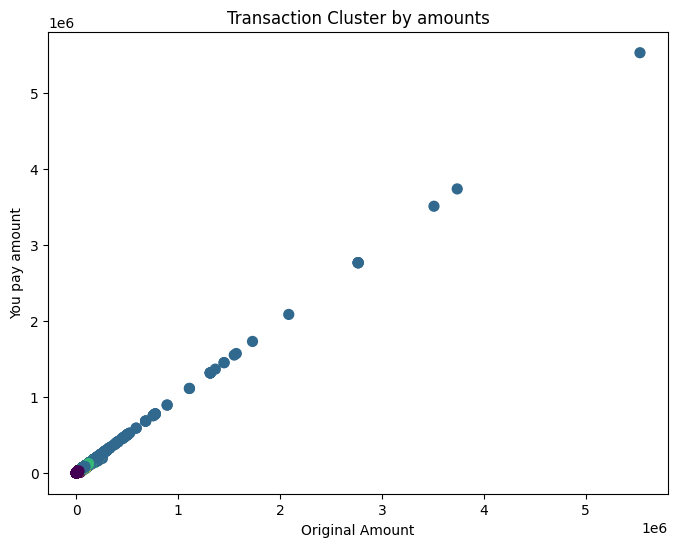

In [3]:
df['transaction_time'] = pd.to_datetime(df['transaction_time'], errors='coerce')
print(df['transaction_time'].dtypes)
df['txn_hour'] = df['transaction_time'].dt.hour
df['txn_month'] = df['transaction_time'].dt.month
df['txn_day'] =df['transaction_time'].dt.day

numeric_features = ['original_amount','you_pay_amount','effective_pay_amount',
                    'emi_tenure','emi_installment_value','total_interest',
                    'total_cost','interest_value','capture_amount']
X = df[numeric_features].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
kmeans = KMeans(n_clusters =4, random_state = 42)
df['cluster'] = kmeans.fit_predict(X_scaled)
print(df[['transaction_id', 'original_amount', 'you_pay_amount', 'cluster']].head())

import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(df['original_amount'], df['you_pay_amount'], c=df['cluster'], cmap = 'viridis', s=50)
plt.xlabel("Original Amount")
plt.ylabel("You pay amount")
plt.title("Transaction Cluster by amounts")
plt.show()

In [4]:
print("Total rows with clusters", df.shape[0])
print(df['cluster'].value_counts())

Total rows with clusters 1200000
cluster
0    1153268
1      27263
3      16420
2       3049
Name: count, dtype: int64


In [5]:
import numpy as np
df['cluster']= df['cluster'].astype(str)
X = df[['original_amount', 'you_pay_amount', 'emi_tenure', 
    'txn_hour', 'txn_day', 'txn_month', 'payment_instrument', 'card_type', 'transaction_status',
    'effective_pay_amount', 'response_code', 'auth_mode', 
    'biometric_executed', 'fallback_request',
    'cluster'
       ]]
y=df['fraud_recommendation']
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=42)
df['log_original_amount'] =np.log1p(df['original_amount'])
df['log_you_pay_amount'] = np.log1p(df['you_pay_amount'])

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[['log_original_amount', 'log_you_pay_amount']])

kmeans = KMeans(n_clusters=4, random_state= 42, n_init=10)
df['cluster'] = kmeans.fit_predict(scaled_data).astype(str)
print("Updated Cluster Classification")
print(df['cluster'].value_counts())

Updated Cluster Classification
cluster
0    589794
3    353552
1    174558
2     82096
Name: count, dtype: int64


In [32]:
    from sklearn.preprocessing import OneHotEncoder
    from sklearn.compose import ColumnTransformer
    from sklearn.impute import SimpleImputer
    from sklearn.pipeline import Pipeline
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import train_test_split
    import pandas as pd
    
    categorical_cols = ['payment_instrument', 'card_type', 'transaction_status',
                        'response_code', 'auth_mode', 'biometric_executed',
                        'fallback_request', 'cluster']
    numerical_cols = ['original_amount', 'you_pay_amount', 'emi_tenure',
                      'txn_hour', 'txn_day', 'txn_month', 'effective_pay_amount']
    
    for col in categorical_cols:
        X[col] = X[col].where(X[col].isna(), X[col].astype(str))

    y = y.fillna('Unknown_Status')

    numeric_transformer = SimpleImputer(strategy='median')
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ])
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numerical_cols),
            ('cat', categorical_transformer, categorical_cols)
        ])
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Full pipeline: preprocessing + model
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('model', RandomForestClassifier(n_estimators=100, random_state=42))])
    
    # Fit model
    clf.fit(X_train, y_train)
    
    # Feature importance
    importances = clf.named_steps['model'].feature_importances_
    feature_names = clf.named_steps['preprocessor'].get_feature_names_out()
    importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    
    print(importance_df.sort_values(by='Importance', ascending=False).head(10))


                               Feature  Importance
29                  cat__card_type_nan    0.163586
21  cat__payment_instrument_UPI_INTENT    0.152870
22               cat__card_type_CREDIT    0.131438
7          cat__payment_instrument_COD    0.095668
9       cat__payment_instrument_CREDIT    0.079226
11  cat__payment_instrument_DYNAMIC_QR    0.063560
4                         num__txn_day    0.038110
1                  num__you_pay_amount    0.028456
0                 num__original_amount    0.028017
6            num__effective_pay_amount    0.025327
